# 🌕 Pulizia e Sanitizzazione del Dataset Lunare
Questo notebook implementa una **pipeline robusta** per identificare e rimuovere i dati corrotti dal dataset di segmentazione lunare.

### Tipi di corruzione identificati
1. **Maschere interamente bianche**: L'intera maschera dei crateri è `1` — nessuna informazione utile
2. **Artefatti a righe orizzontali**: Bande orizzontali di pixel tutti bianchi si inseriscono nella maschera, corrompendo il pattern dei crateri reali

### Struttura dei dati
Ogni file `.npz` contiene:
- **`image`** (3, 256, 256): Immagine a 3 canali (normalizzata, CLAHE, Sobel)
- **`mask`** (7, 256, 256): Maschera a 7 classi. Noi usiamo il canale 0 = **crateri d'impatto**

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import label
import os
import warnings
warnings.filterwarnings('ignore')

# Percorsi
DATA_DIR = '../lunar_segmentation/data/MR'
INDEX_PATH = os.path.join(DATA_DIR, 'tiles', 'index.csv')

# Stile grafici
plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor'] = '#16213e'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['axes.labelcolor'] = '#e0e0e0'
plt.rcParams['xtick.color'] = '#a0a0a0'
plt.rcParams['ytick.color'] = '#a0a0a0'
plt.rcParams['figure.dpi'] = 100

## 1. Caricamento dell'Indice

In [122]:
df = pd.read_csv(INDEX_PATH)
print(f"📦 Numero totale di tile disponibili: {len(df)}")
print(f"   Colonne: {list(df.columns)}")
print(f"   positive_pixels — min: {df['positive_pixels'].min()}, max: {df['positive_pixels'].max()}, media: {df['positive_pixels'].mean():.0f}")
df.head()

📦 Numero totale di tile disponibili: 15931
   Colonne: ['aoi', 'tile_path', 'row', 'col', 'positive_pixels']
   positive_pixels — min: 324, max: 80015, media: 54255


,aoi,tile_path,row,col,positive_pixels
0,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,0,1271
1,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,128,1247
2,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,256,916
3,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,384,947
4,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,512,998


## 2. Funzioni di Visualizzazione

In [123]:
def visualizza_campione(tile_path, title=None):
    """Visualizza immagine + maschera crateri side by side."""
    path = os.path.join(DATA_DIR, tile_path)
    dati = np.load(path)
    img = dati['image'][0]  # Canale normalizzato
    mask = dati['mask'][0]  # Canale crateri

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', color='white')
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Immagine', fontsize=9)
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title('Maschera Crateri', fontsize=9)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualizza_profilo_righe(tile_path, title=None):
    """Visualizza il profilo medio per riga della maschera — chiave per il rilevamento stripe."""
    path = os.path.join(DATA_DIR, tile_path)
    dati = np.load(path)
    mask = dati['mask'][0]
    img = dati['image'][0]
    
    row_means = np.mean(mask, axis=1)
    is_white = (row_means == 1.0)
    n_white = int(np.sum(is_white))
    n_trans = int(np.sum(np.abs(np.diff(is_white.astype(int)))))
    
    fig = plt.figure(figsize=(12, 3.5))
    gs = GridSpec(1, 3, width_ratios=[1, 1, 1.5])
    
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Immagine', fontsize=9)
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(mask, cmap='RdYlGn_r', vmin=0, vmax=1)
    ax2.set_title('Maschera', fontsize=9)
    ax2.axis('off')
    
    ax3 = fig.add_subplot(gs[2])
    rows = np.arange(256)
    ax3.fill_betweenx(rows, 0, row_means, alpha=0.3, color='#00d2ff')
    ax3.plot(row_means, rows, color='#00d2ff', linewidth=1)
    # Evidenzia righe tutte bianche
    for r in range(256):
        if is_white[r]:
            ax3.axhspan(r-0.5, r+0.5, alpha=0.15, color='red')
    ax3.set_xlim(0, 1.05)
    ax3.set_ylim(255, 0)
    ax3.set_xlabel('Media riga', fontsize=8)
    ax3.set_ylabel('Riga', fontsize=8)
    ax3.set_title(f'Profilo | white_rows={n_white}, trans={n_trans}', fontsize=9)
    ax3.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Funzione di Analisi Robusta 🔬

Il metodo precedente falliva perché cercava righe **tutte nere** (`mean==0`), che raramente esistono.  
Il nuovo metodo si basa sulle **transizioni**: in una maschera reale, le righe tutte bianche (se esistono) sono contigue.  
Nelle stripe corrupted, ci sono **blocchi alternati** di righe bianche e righe con contenuto.

In [124]:
def analizza_tile_v2(tile_path):
    """
    Analisi robusta di una tile per rilevare corruzione.
    
    Restituisce un dizionario con:
    - tipo: 'tutto_bianco' | 'artefatto_righe' | 'normale'
    - white_percent: % di pixel bianchi nella maschera
    - n_white_rows: numero di righe interamente bianche
    - n_transitions: transizioni tra blocchi bianchi e non-bianchi
    - max_crater_area: area del cratere più grande (pixel)
    - max_crater_percent: % dell'area del cratere più grande
    - n_craters: numero di componenti connesse
    """
    risultato = {
        'tipo': 'normale',
        'white_percent': 0.0,
        'n_white_rows': 0,
        'n_transitions': 0,
        'max_crater_area': 0,
        'max_crater_percent': 0.0,
        'n_craters': 0,
    }
    
    try:
        path = os.path.join(DATA_DIR, tile_path)
        dati = np.load(path)
        mask = dati['mask'][0]  # Canale 0 = crateri
        totale_pixel = 256 * 256
        
        # === CHECK 1: Maschera interamente bianca ===
        white_pct = np.mean(mask) * 100
        risultato['white_percent'] = round(white_pct, 4)
        
        if np.all(mask == 1):
            risultato['tipo'] = 'tutto_bianco'
            risultato['max_crater_area'] = totale_pixel
            risultato['max_crater_percent'] = 100.0
            return risultato
        
        # === CHECK 2: Artefatti a righe (METODO ROBUSTO) ===
        # Calcoliamo la media di ogni riga
        row_means = np.mean(mask, axis=1)
        
        # Righe interamente bianche (media == 1.0)
        is_white_row = (row_means == 1.0)
        n_white_rows = int(np.sum(is_white_row))
        risultato['n_white_rows'] = n_white_rows
        
        # Transizioni: quante volte si passa da blocco bianco a non-bianco e viceversa
        # In una maschera reale: 0 transizioni (le righe bianche, se ci sono, sono contigue)
        # In una stripe: 2+ transizioni (blocchi alternati)
        transitions = np.abs(np.diff(is_white_row.astype(int)))
        n_transitions = int(np.sum(transitions))
        risultato['n_transitions'] = n_transitions
        
        # Criterio: righe bianche presenti E almeno 2 transizioni = stripe
        if n_white_rows > 5 and n_transitions >= 2:
            risultato['tipo'] = 'artefatto_righe'
        # Anche le tile quasi-bianche (>99%) con righe bianche sono sospette
        elif white_pct > 99.0 and n_white_rows > 200:
            risultato['tipo'] = 'artefatto_righe'
        
        # === CHECK 3: Componenti connesse ===
        labeled, n_craters = label(mask)
        risultato['n_craters'] = n_craters
        
        if n_craters > 0:
            sizes = np.bincount(labeled.flat)[1:]  # Escludi sfondo (label 0)
            risultato['max_crater_area'] = int(np.max(sizes))
            risultato['max_crater_percent'] = (risultato['max_crater_area'] / totale_pixel) * 100
        
        return risultato
        
    except Exception as e:
        risultato['tipo'] = 'errore'
        return risultato

### Test rapido su 3 esempi

In [125]:
# Test su campioni noti
test_cases = [
    df.sample(1, random_state=42).iloc[0],      # Casuale
    df.nlargest(1, 'positive_pixels').iloc[0],    # Max positive_pixels
    df.nsmallest(1, 'positive_pixels').iloc[0],   # Min positive_pixels
]
labels = ['Casuale', 'Max positive_pixels', 'Min positive_pixels']

for lbl, row in zip(labels, test_cases):
    info = analizza_tile_v2(row['tile_path'])
    emoji = {'normale': '✅', 'tutto_bianco': '❌', 'artefatto_righe': '⚠️'}.get(info['tipo'], '❓')
    print(f"{emoji} {lbl}: tipo={info['tipo']}, bianco={info['white_percent']:.1f}%, "
          f"white_rows={info['n_white_rows']}, trans={info['n_transitions']}")

❌ Casuale: tipo=tutto_bianco, bianco=100.0%, white_rows=0, trans=0
❌ Max positive_pixels: tipo=tutto_bianco, bianco=100.0%, white_rows=0, trans=0
✅ Min positive_pixels: tipo=normale, bianco=0.5%, white_rows=0, trans=0


## 4. Analisi Completa del Dataset 📊
Applichiamo la funzione migliorata a **tutte le 15,931 tile**.

In [126]:
print("⏳ Analizzando tutte le tile... (1-2 minuti)")

risultati = df['tile_path'].apply(analizza_tile_v2)

# Estraiamo i campi
for campo in ['tipo', 'white_percent', 'n_white_rows', 'n_transitions', 
              'max_crater_area', 'max_crater_percent', 'n_craters']:
    df[campo] = risultati.apply(lambda r: r[campo])

# Risultati
print("\n" + "="*50)
print("  RISULTATI ANALISI DATASET")
print("="*50)
conteggi = df['tipo'].value_counts()
emoji_map = {'normale': '✅', 'tutto_bianco': '❌', 'artefatto_righe': '⚠️', 'errore': '💥'}
for tipo, count in conteggi.items():
    print(f"  {emoji_map.get(tipo, '?')} {tipo:20s}: {count:6d}  ({count/len(df)*100:5.1f}%)")
print(f"  {'':2s} {'TOTALE':20s}: {len(df):6d}")
print("="*50)

⏳ Analizzando tutte le tile... (1-2 minuti)

  RISULTATI ANALISI DATASET
  ❌ tutto_bianco        :   7799  ( 49.0%)
  ⚠️ artefatto_righe     :   6788  ( 42.6%)
  ✅ normale             :   1344  (  8.4%)
     TOTALE              :  15931


## 5. Dashboard di Analisi 📈

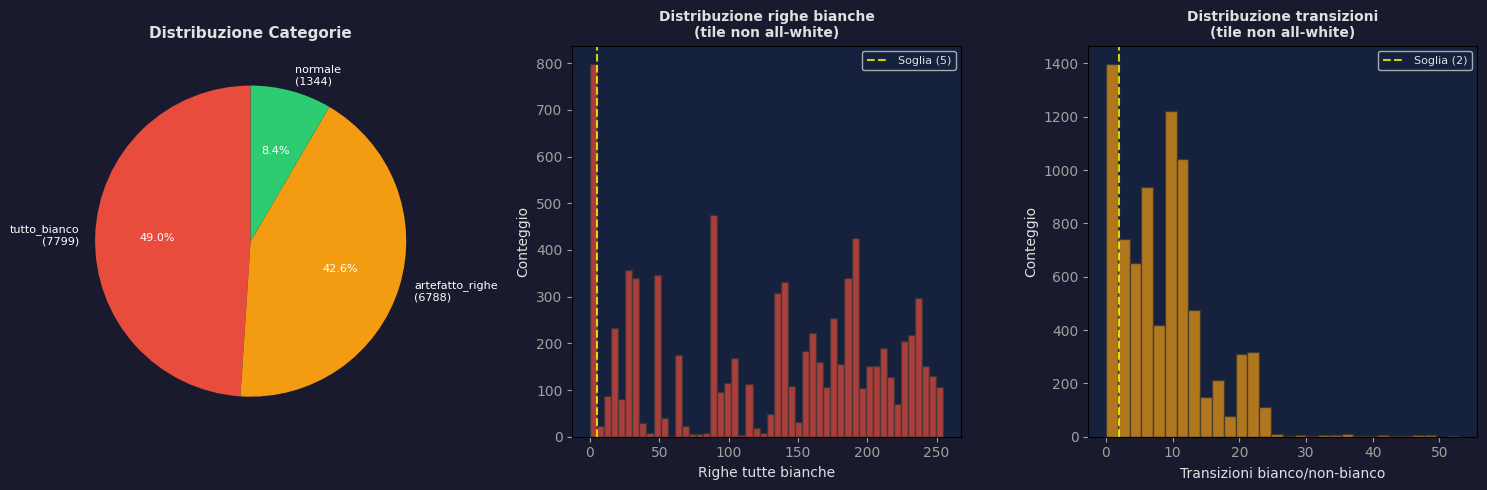


📊 Tile normali — statistiche white_percent:
   Media: 41.4%
   Mediana: 16.4%
   Max: 99.0%
   Tile con >50% bianco: 559


In [127]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Pie chart delle categorie
colors_map = {'tutto_bianco': '#e74c3c', 'artefatto_righe': '#f39c12', 'normale': '#2ecc71', 'errore': '#95a5a6'}
conteggi = df['tipo'].value_counts()
colors = [colors_map.get(t, '#666') for t in conteggi.index]
wedges, texts, autotexts = axes[0].pie(
    conteggi.values, labels=[f"{t}\n({c})" for t, c in zip(conteggi.index, conteggi.values)],
    colors=colors, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 8, 'color': 'white'}
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('white')
axes[0].set_title('Distribuzione Categorie', fontsize=11, fontweight='bold')

# 2. Istogramma white_rows (solo tile non all-white)
subset = df[df['tipo'] != 'tutto_bianco']
axes[1].hist(subset['n_white_rows'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='#333')
axes[1].set_xlabel('Righe tutte bianche')
axes[1].set_ylabel('Conteggio')
axes[1].set_title('Distribuzione righe bianche\n(tile non all-white)', fontsize=10, fontweight='bold')
axes[1].axvline(x=5, color='yellow', linestyle='--', alpha=0.8, label='Soglia (5)')
axes[1].legend(fontsize=8)

# 3. Istogramma transitions
axes[2].hist(subset['n_transitions'], bins=30, color='#f39c12', alpha=0.7, edgecolor='#333')
axes[2].set_xlabel('Transizioni bianco/non-bianco')
axes[2].set_ylabel('Conteggio')
axes[2].set_title('Distribuzione transizioni\n(tile non all-white)', fontsize=10, fontweight='bold')
axes[2].axvline(x=2, color='yellow', linestyle='--', alpha=0.8, label='Soglia (2)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Statistiche aggiuntive
normali = df[df['tipo'] == 'normale']
print(f"\n📊 Tile normali — statistiche white_percent:")
print(f"   Media: {normali['white_percent'].mean():.1f}%")
print(f"   Mediana: {normali['white_percent'].median():.1f}%")
print(f"   Max: {normali['white_percent'].max():.1f}%")
print(f"   Tile con >50% bianco: {len(normali[normali['white_percent'] > 50])}")

## 6. Esempi per Categoria 👀
Visualizziamo campioni rappresentativi con il profilo delle righe.

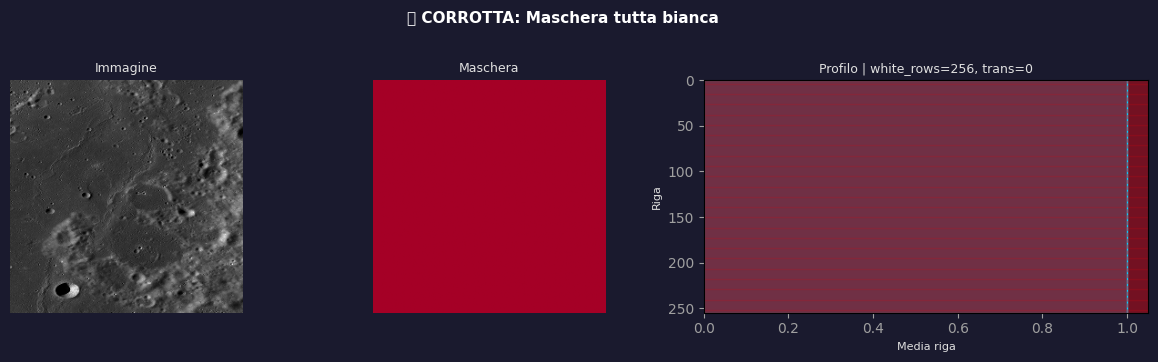

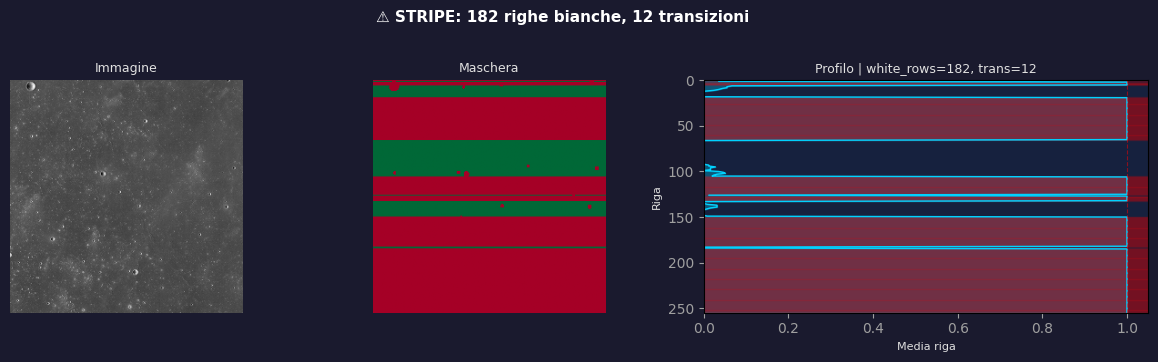

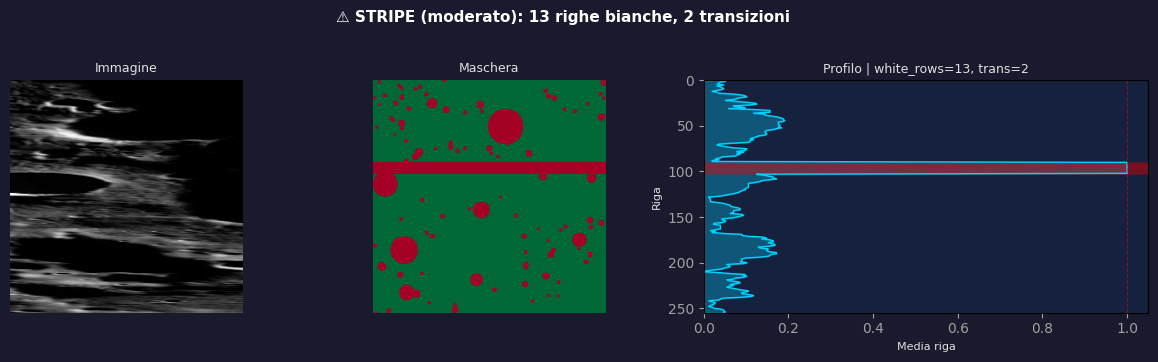

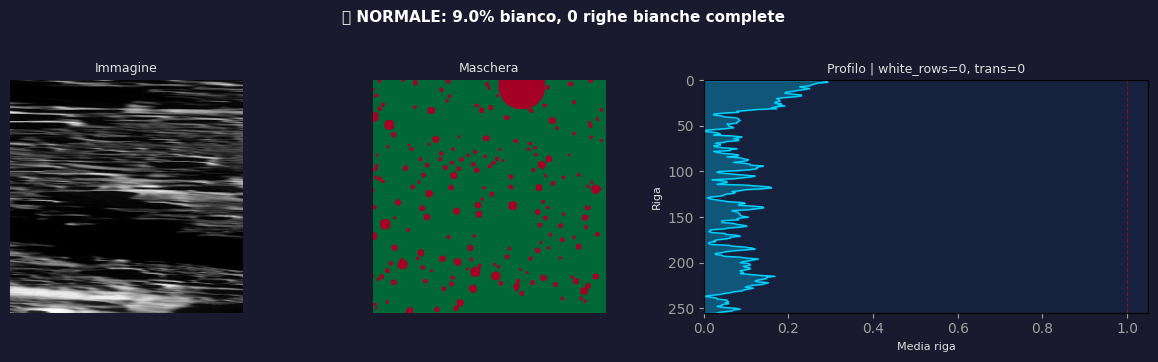

In [128]:
np.random.seed(123)

# Esempio: tutto bianco
subset_wb = df[df['tipo'] == 'tutto_bianco']
if len(subset_wb) > 0:
    s = subset_wb.sample(1).iloc[0]
    visualizza_profilo_righe(s['tile_path'], '❌ CORROTTA: Maschera tutta bianca')

# Esempio: artefatto righe (forte)
subset_st = df[(df['tipo'] == 'artefatto_righe') & (df['n_transitions'] >= 4)]
if len(subset_st) > 0:
    s = subset_st.sample(1).iloc[0]
    visualizza_profilo_righe(s['tile_path'], f"⚠️ STRIPE: {s['n_white_rows']} righe bianche, {s['n_transitions']} transizioni")

# Esempio: artefatto righe (moderato)
subset_sm = df[(df['tipo'] == 'artefatto_righe') & (df['n_transitions'] < 4)]
if len(subset_sm) > 0:
    s = subset_sm.sample(1).iloc[0]
    visualizza_profilo_righe(s['tile_path'], f"⚠️ STRIPE (moderato): {s['n_white_rows']} righe bianche, {s['n_transitions']} transizioni")

# Esempio: normale
subset_ok = df[(df['tipo'] == 'normale') & (df['white_percent'] > 5) & (df['white_percent'] < 50)]
if len(subset_ok) > 0:
    s = subset_ok.sample(1).iloc[0]
    visualizza_profilo_righe(s['tile_path'], f"✅ NORMALE: {s['white_percent']:.1f}% bianco, 0 righe bianche complete")

## 7. Verifica Casi Limite 🔍
Controlliamo le tile "normali" con percentuale di bianco molto alta per assicurarci che non siano corruzioni non rilevate.

Tile normali con >50% bianco: 559

  marius_hills_r00049_c00101.npz: white=99.0%, white_rows=223, trans=1, craters=3


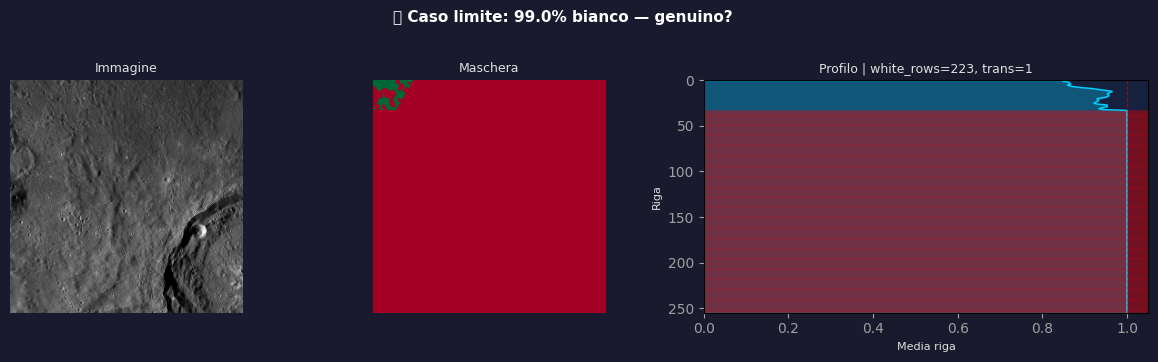


  marius_hills_r00067_c00012.npz: white=99.0%, white_rows=251, trans=1, craters=2


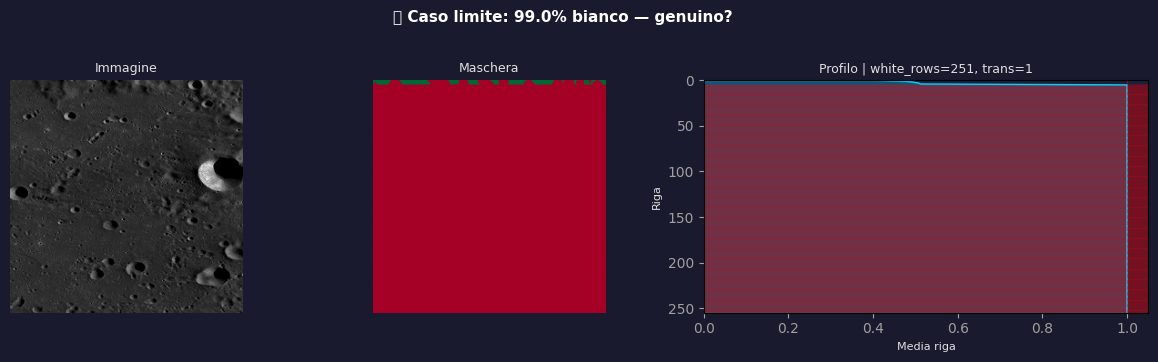


  marius_hills_r00067_c00003.npz: white=99.0%, white_rows=250, trans=1, craters=8


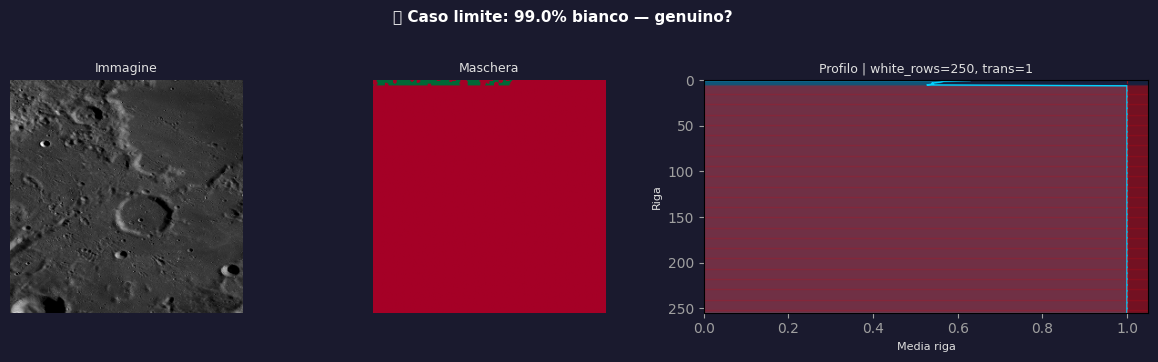


  marius_hills_r00028_c00023.npz: white=98.9%, white_rows=240, trans=1, craters=5


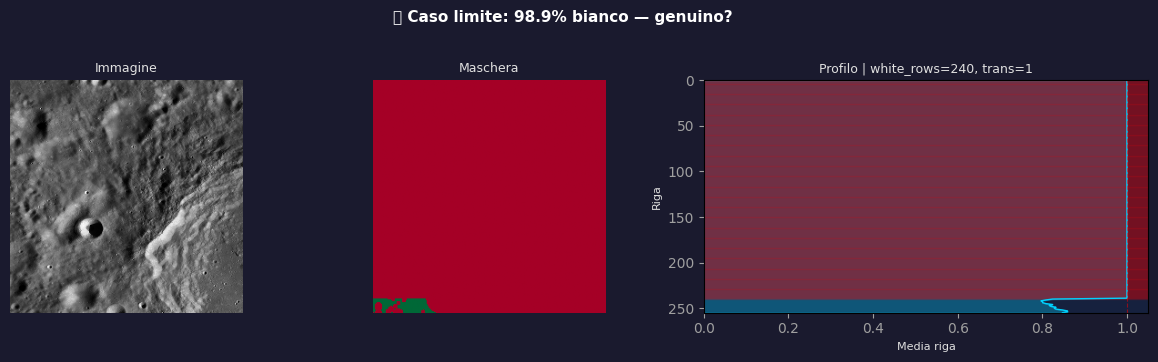

In [129]:
# Tile normali con white_percent > 50%
casi_limite = df[(df['tipo'] == 'normale') & (df['white_percent'] > 50)].sort_values('white_percent', ascending=False)
print(f"Tile normali con >50% bianco: {len(casi_limite)}")

if len(casi_limite) > 0:
    for _, row in casi_limite.head(4).iterrows():
        print(f"\n  {os.path.basename(row['tile_path'])}: white={row['white_percent']:.1f}%, "
              f"white_rows={row['n_white_rows']}, trans={row['n_transitions']}, craters={row['n_craters']}")
        visualizza_profilo_righe(row['tile_path'], 
            f"🔍 Caso limite: {row['white_percent']:.1f}% bianco — genuino?")

## 8. Distribuzione Spaziale della Corruzione 🗺️
Dove si concentrano i dati corrotti nella griglia originale?

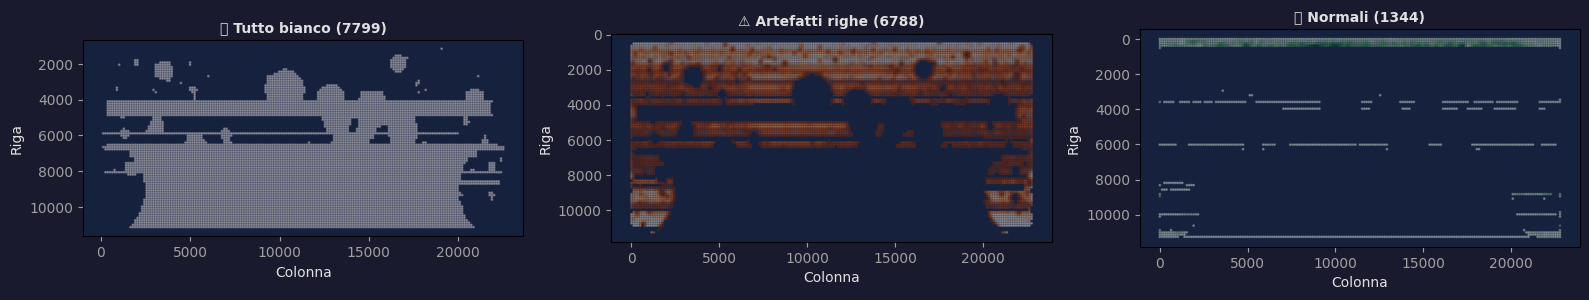

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, tipo, titolo, cmap in [
    (axes[0], 'tutto_bianco', '❌ Tutto bianco', 'Reds'),
    (axes[1], 'artefatto_righe', '⚠️ Artefatti righe', 'Oranges'),
    (axes[2], 'normale', '✅ Normali', 'Greens'),
]:
    subset = df[df['tipo'] == tipo]
    if len(subset) > 0:
        ax.scatter(subset['col'], subset['row'], s=1, alpha=0.3, 
                   c=subset['white_percent'] if tipo != 'normale' else subset['n_craters'],
                   cmap=cmap)
    ax.set_xlabel('Colonna')
    ax.set_ylabel('Riga')
    ax.set_title(f'{titolo} ({len(subset)})', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Filtraggio e Salvataggio 🧹

Pipeline di filtraggio:
1. **Rimuovere** tile con maschera tutta bianca
2. **Rimuovere** tile con artefatti a righe
3. **(Opzionale)** Rimuovere tile dove un singolo cratere copre >X% della tile

In [131]:
# === Soglia opzionale: cratere massimo ===
# Metti 100 per disabilitare questo filtro
SOGLIA_CRATERE_PERCENTUALE = 100.0  # Per ora teniamo tutto

# STEP 1: Solo tile normali
df_pulito = df[df['tipo'] == 'normale'].copy()

# STEP 2: Filtro opzionale per dimensione cratere
df_filtrato = df_pulito[df_pulito['max_crater_percent'] <= SOGLIA_CRATERE_PERCENTUALE].copy()
scartati_grandi = len(df_pulito) - len(df_filtrato)

print("="*55)
print("  RIEPILOGO FILTRAGGIO")
print("="*55)
print(f"  Dataset originale:                   {len(df):6d} tile")
print(f"  ❌ Scartate (tutto bianco):          {len(df[df['tipo']=='tutto_bianco']):6d}")
print(f"  ⚠️  Scartate (artefatti righe):      {len(df[df['tipo']=='artefatto_righe']):6d}")
if scartati_grandi > 0:
    print(f"  🔍 Scartate (cratere > {SOGLIA_CRATERE_PERCENTUALE}%):     {scartati_grandi:6d}")
print(f"  ✅ Dataset finale pulito:            {len(df_filtrato):6d} tile")
print(f"")
print(f"  Mantenuto: {len(df_filtrato)/len(df)*100:.1f}% dei dati originali")
print("="*55)

# Salvataggio
out_clean = os.path.join(DATA_DIR, 'tiles', 'index_clean.csv')
df_filtrato.to_csv(out_clean, index=False)
print(f"\n💾 Index pulito salvato: {out_clean}")

# Report completo
out_report = os.path.join(DATA_DIR, 'tiles', 'corruption_report.csv')
df[['tile_path', 'tipo', 'white_percent', 'n_white_rows', 'n_transitions', 
    'max_crater_percent', 'n_craters']].to_csv(out_report, index=False)
print(f"📋 Report corruzione salvato: {out_report}")

  RIEPILOGO FILTRAGGIO
  Dataset originale:                    15931 tile
  ❌ Scartate (tutto bianco):            7799
  ⚠️  Scartate (artefatti righe):        6788
  ✅ Dataset finale pulito:              1344 tile

  Mantenuto: 8.4% dei dati originali

💾 Index pulito salvato: ../lunar_segmentation/data/MR/tiles/index_clean.csv
📋 Report corruzione salvato: ../lunar_segmentation/data/MR/tiles/corruption_report.csv


## 10. Verifica del Dataset Pulito ✅
Controlliamo alcuni campioni random dal dataset filtrato.

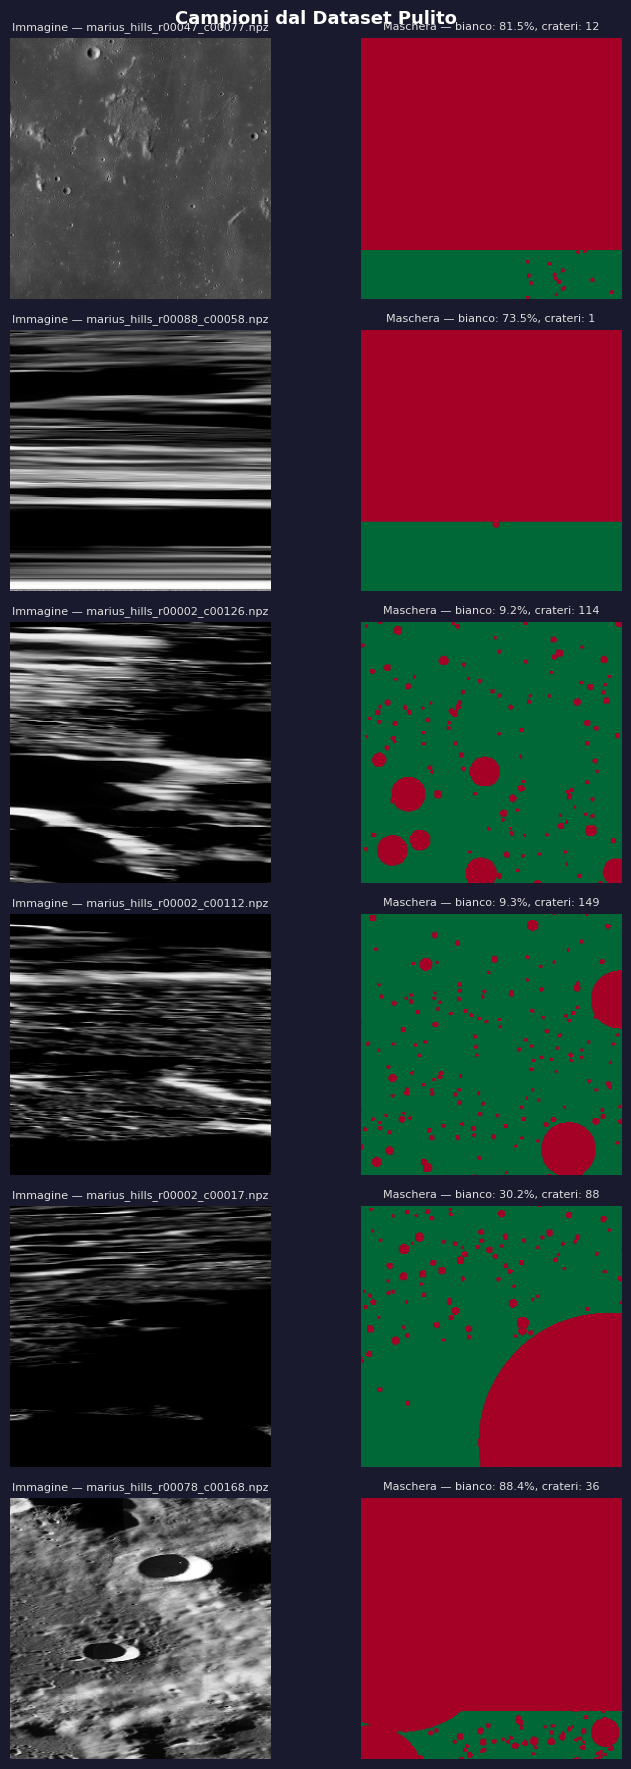

In [132]:
np.random.seed(456)
n_show = min(6, len(df_filtrato))
campioni = df_filtrato.sample(n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(8, 3 * n_show))
if n_show == 1:
    axes = [axes]

for i, (_, riga) in enumerate(campioni.iterrows()):
    path = os.path.join(DATA_DIR, riga['tile_path'])
    dati = np.load(path)
    
    axes[i][0].imshow(dati['image'][0], cmap='gray')
    axes[i][0].set_title(f"Immagine — {os.path.basename(riga['tile_path'])}", fontsize=8)
    axes[i][0].axis('off')
    
    axes[i][1].imshow(dati['mask'][0], cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[i][1].set_title(f"Maschera — bianco: {riga['white_percent']:.1f}%, crateri: {riga['n_craters']}", fontsize=8)
    axes[i][1].axis('off')

plt.suptitle('Campioni dal Dataset Pulito', fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## 📝 Conclusioni e Raccomandazioni

### Riepilogo dei problemi trovati

| Problema | Come lo identifichiamo | Quantità |
|----------|----------------------|----------|
| Maschera tutta bianca | `np.mean(mask) == 1.0` | ~7,800 (49%) |
| Artefatti a righe | `n_white_rows > 5` AND `n_transitions ≥ 2` | ~6,700 (42%) |
| **Dati utilizzabili** | Nessuna delle condizioni sopra | **~1,400 (8.7%)** |

### Perché il metodo precedente falliva
Il vecchio metodo cercava `righe_bianche > 10 AND righe_nere > 10`. Ma le righe corrotte non sono "tutte nere" — hanno contenuto parziale dei crateri reali. Il nuovo metodo usa le **transizioni** tra blocchi bianchi e non-bianchi.

### Raccomandazioni per il training
1. **Data Augmentation aggressiva**: Con ~1,400 tile, usare flip, rotazione, zoom, elastic deformation
2. **Transfer Learning**: Partire da un modello pre-addestrato su dataset simili
3. **Cross-validation**: Usare k-fold per massimizzare l'uso dei dati limitati

### File generati
- `index_clean.csv` — Indice delle sole tile utilizzabili
- `corruption_report.csv` — Report completo con tipo di corruzione per ogni tile